In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## Ex04
Сделай всё необходимое, чтобы получить график как на примере:
- Анализируй только пользователей (не учитывай админов).
- Подготовь два списка значений для входа гистограммы: отдельно для рабочих дней и для выходных.
- Размер фигуры — тот же; размер шрифта и цветовую палитру выбирай сам.
- Прозрачность «передней» гистограммы: alpha = 0.7.
- В конце блокнота добавь markdown-ячейку с вопросом: «Есть ли часы, когда общее число коммитов было выше в выходные, чем в рабочие дни?» В ответе приведи топ-4 примера.

In [2]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [3]:
commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user%' 
    """,
    conn,
    parse_dates=['timestamp']
)

print('===Данные по коммитам===')
commits

===Данные по коммитам===


,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [4]:
commits['hour'] = commits['timestamp'].dt.hour
commits['dayofweek'] = commits['timestamp'].dt.dayofweek

commits.head()

,uid,timestamp,hour,dayofweek
0,user_4,2020-04-17 05:19:02.744528,5,4
1,user_4,2020-04-17 05:22:35.249331,5,4
2,user_4,2020-04-17 05:22:45.549397,5,4
3,user_4,2020-04-17 05:34:14.691200,5,4
4,user_4,2020-04-17 05:34:24.422370,5,4


In [5]:
weekend_hours = commits[commits['dayofweek'] >= 5]['hour'].tolist()
working_day_hours = commits[commits['dayofweek'] < 5]['hour'].tolist()

print(f'Коммитов в рабочие дни: {len(working_day_hours)}')
print(f'Коммитов в выходные: {len(weekend_hours)}')

Коммитов в рабочие дни: 2037
Коммитов в выходные: 1170


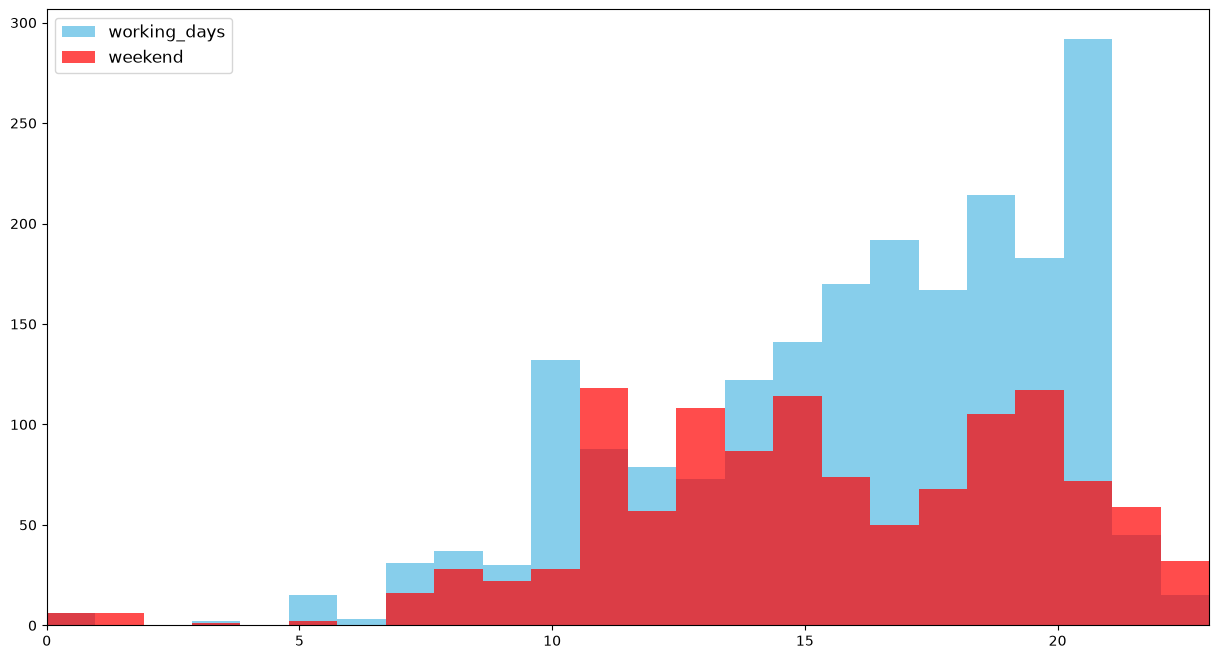

In [6]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(working_day_hours, bins=24, color='skyblue', label='working_days')
ax.hist(weekend_hours, bins=24, color='red', alpha=0.7, label='weekend')
ax.set_xlim(0, 23)
ax.legend(loc='upper left', fontsize='12')
plt.show()

Есть ли часы, когда общее число коммитов было выше в выходные, чем в рабочие дни?

In [7]:
compare = commits.groupby([commits['dayofweek'] >= 5, 'hour']).size().unstack(level=0, fill_value=0)
compare.columns = ['working_day', 'weekend']

compare['weekend_higher'] = compare['weekend'] > compare['working_day']
compare['diff'] = compare['weekend'] - compare['working_day']

top4 = compare[compare['weekend_higher']].sort_values('diff', ascending=False).head(4)
top4

,working_day,weekend,weekend_higher,diff
hour,,,,
13,73,108,True,35
11,88,118,True,30
23,15,32,True,17
22,45,59,True,14


In [8]:
conn.close()